## Revision : LSTM

##### basic overlook at the LSTM based concepts, targeting single feature 
##### and trying to get back to the concepts

In [1]:
### Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas_datareader as pdr
import os
from dotenv import load_dotenv

In [2]:
### api key, keeping it hidden
load_dotenv('../keys.txt')
key = os.getenv('key')

In [41]:
### loading the data for Microsoft
df_MSFT = pdr.get_data_tiingo('MSFT', api_key = key)
df_MSFT.head()

close    high     low    open    volume  \
symbol date                                                                  
MSFT   2021-04-30 00:00:00+00:00  252.18  253.08  249.60  249.74  30945098   
       2021-05-03 00:00:00+00:00  251.86  254.35  251.12  253.40  19626568   
       2021-05-04 00:00:00+00:00  247.79  251.21  245.76  250.97  32756052   
       2021-05-05 00:00:00+00:00  246.47  249.50  245.82  249.06  21901325   
       2021-05-06 00:00:00+00:00  249.73  249.86  244.69  246.45  26491085   

                                    adjClose     adjHigh      adjLow  \
symbol date                                                            
MSFT   2021-04-30 00:00:00+00:00  241.962204  242.825738  239.486740   
       2021-05-03 00:00:00+00:00  241.655169  244.044280  240.945153   
       2021-05-04 00:00:00+00:00  237.750077  241.031506  235.802328   
       2021-05-05 00:00:00+00:00  236.483561  239.390792  235.859897   
       2021-05-06 00:00:00+00:00  239.611472  239.736205  234.775683   

                                     adjOpen  adjVolume  divCash  splitFactor  
symbol date                                                                    
MSFT   2021-04-30 00:00:00+00:00  239.621067   30945098      0.0          1.0  
       2021-05-03 00:00:00+00:00  243.132772   19626568      0.0          1.0  
       2021-05-04 00:00:00+00:00  240.801230   32756052      0.0          1.0  
       2021-05-05 00:00:00+00:00  238.968619   21901325      0.0          1.0  
       2021-05-06 00:00:00+00:00  236.464371   26491085      0.0          1.0

In [42]:
### tageting the 4 features at the time : close, high, low and open
features_to_target = ['close', 'high', 'low', 'open']
df_stock_MSFT = df_MSFT[features_to_target].values
df_stock_MSFT

array([[252.18  , 253.08  , 249.6   , 249.74  ],
       [251.86  , 254.35  , 251.12  , 253.4   ],
       [247.79  , 251.21  , 245.76  , 250.97  ],
       ...,
       [424.82  , 427.11  , 417.0701, 422.375 ],
       [429.25  , 429.92  , 421.9   , 424.57  ],
       [424.46  , 426.82  , 420.29  , 424.575 ]])

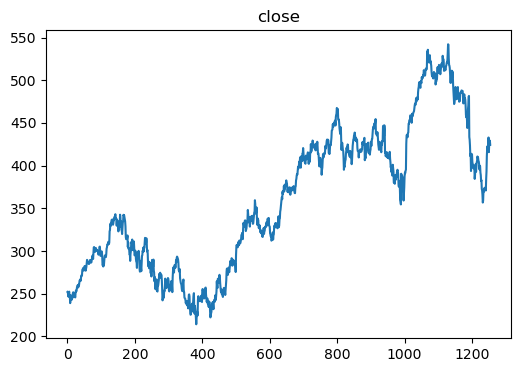

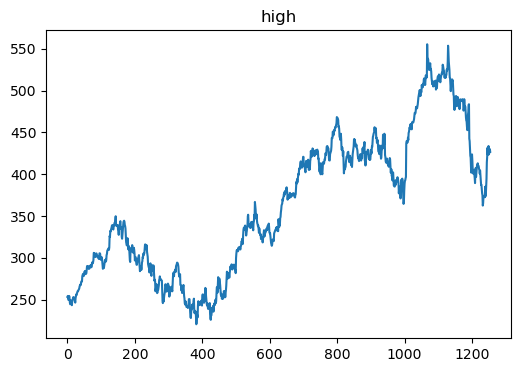

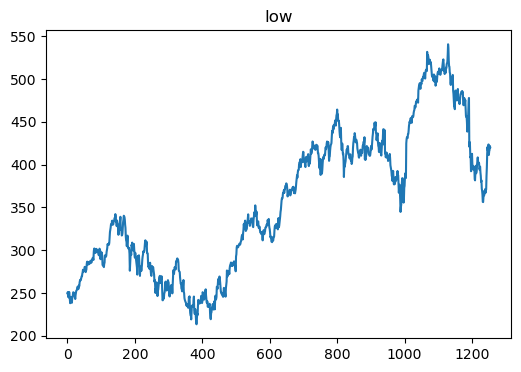

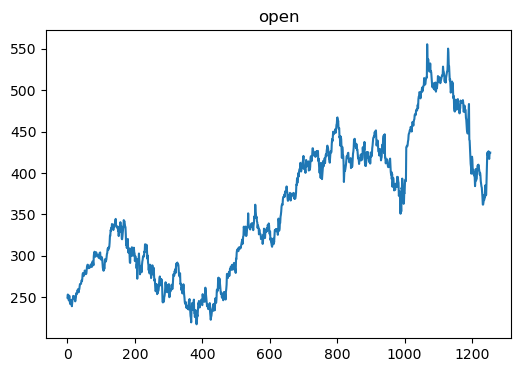

In [5]:
### plotting the graphs
for i in range (0, 4) : 
    plt.figure(figsize = (6, 4))
    plt.title(features_to_target[i])
    plt.plot(df_stock_MSFT[:, i])

In [43]:
### applying the minmax scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
df_stock_MSFT = scaler.fit_transform(df_stock_MSFT)
df_stock_MSFT

array([[0.11570374, 0.09751074, 0.11049401, 0.09532835],
       [0.11472759, 0.10130134, 0.11513752, 0.10616717],
       [0.10231224, 0.09192932, 0.09876306, 0.0989709 ],
       ...,
       [0.64233421, 0.61694126, 0.62210461, 0.60657437],
       [0.65584772, 0.62532832, 0.63685965, 0.6130747 ],
       [0.64123604, 0.61607569, 0.6319412 , 0.61308951]])

In [7]:
### checking the shape
df_stock_MSFT.shape

(1255, 4)

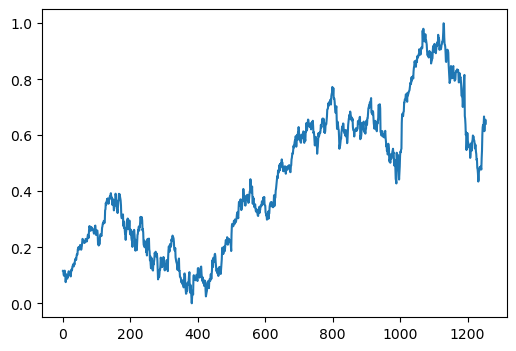

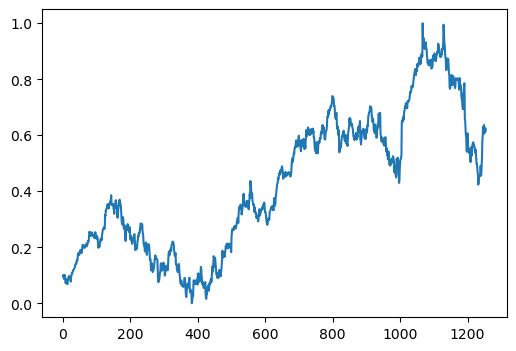

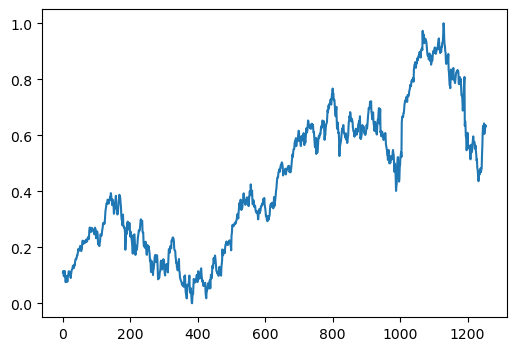

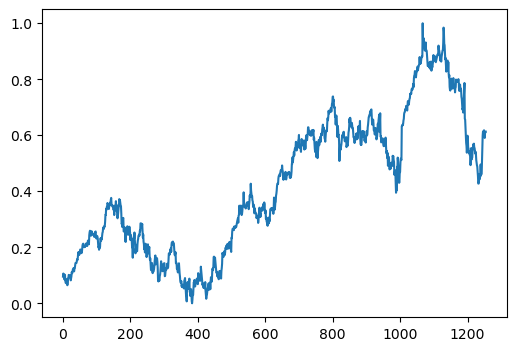

In [44]:
### plotting the graphs again for the comparison
for i in range(0, 4) : 
    plt.figure(figsize = (6, 4))
    plt.plot(df_stock_MSFT[:, i])

In [45]:
### making the sequnces, target 90 days sequence
days = 90
X, y = [], []
for i in range(len(df_stock_MSFT) - days) : 

    X.append(df_stock_MSFT[i : i + days, :])
    y.append(df_stock_MSFT[i + days , :])

X = np.array(X)
y = np.array(y)

In [46]:
### checking the sequnces (X and y)
X

array([[[0.11570374, 0.09751074, 0.11049401, 0.09532835],
        [0.11472759, 0.10130134, 0.11513752, 0.10616717],
        [0.10231224, 0.09192932, 0.09876306, 0.0989709 ],
        ...,
        [0.2650845 , 0.24758298, 0.26501272, 0.25068483],
        [0.26505399, 0.24531399, 0.26525712, 0.2471015 ],
        [0.26212556, 0.24080707, 0.25896395, 0.24714592]],

       [[0.11472759, 0.10130134, 0.11513752, 0.10616717],
        [0.10231224, 0.09192932, 0.09876306, 0.0989709 ],
        [0.09828564, 0.08682545, 0.09894635, 0.09331458],
        ...,
        [0.26505399, 0.24531399, 0.26525712, 0.2471015 ],
        [0.26212556, 0.24080707, 0.25896395, 0.24714592],
        [0.26221707, 0.2393744 , 0.25671888, 0.24351818]],

       [[0.10231224, 0.09192932, 0.09876306, 0.0989709 ],
        [0.09828564, 0.08682545, 0.09894635, 0.09331458],
        [0.10823013, 0.08789995, 0.09549427, 0.08558525],
        ...,
        [0.26212556, 0.24080707, 0.25896395, 0.24714592],
        [0.26221707, 0.239374

In [47]:
### checking the y
y

array([[0.26221707, 0.2393744 , 0.25671888, 0.24351818],
       [0.25318772, 0.24394102, 0.25529802, 0.24659806],
       [0.24849003, 0.23731495, 0.25034903, 0.23947583],
       ...,
       [0.64233421, 0.61694126, 0.62210461, 0.60657437],
       [0.65584772, 0.62532832, 0.63685965, 0.6130747 ],
       [0.64123604, 0.61607569, 0.6319412 , 0.61308951]])

In [48]:
### at 91th index of X should match the 1st index of y
print(f"{X.shape} :: {y.shape}")

(1165, 90, 4) :: (1165, 4)


In [49]:
### veryfying the sequences
X[2][89]

array([0.25318772, 0.24394102, 0.25529802, 0.24659806])

In [50]:
### spliting the train-test data (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [51]:
### checking the shape
print(f"{X_train.shape} : {y_train.shape} :: {X_test.shape} : {y_test.shape}")

(932, 90, 4) : (932, 4) :: (233, 90, 4) : (233, 4)


In [52]:
### importing the tesnorflow libraries to build the model
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout

In [53]:
### building the sequential model
model = Sequential([
    LSTM(50, return_sequences = True, input_shape = (days, 4)),
    Dropout(0.33),
    Bidirectional(LSTM(100)),
    Dropout(0.33),
    Dense(4, activation = 'linear')
])
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mse'])

c:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
### checking the model summary now
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 90, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 90, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 200)            │       120,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,604 (517.98 KB)

 Trainable params: 132,604 (517.98 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
### training the model
model.fit(X_train, y_train, epochs = 40, batch_size = 32, verbose = 1)

Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0853 - mse: 0.0853
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0087 - mse: 0.0087
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0059 - mse: 0.0059
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0059 - mse: 0.0059
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0055 - mse: 0.0055
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0048 - mse: 0.0048
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0050 - mse: 0.0050
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0044 - mse: 0.0044
Epoch 9/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0043 - mse: 0.0043
Epoch 10/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0041 - mse: 0.0041
Epoch 11/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0039 - mse: 0.0039
Epoch 12/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0039 - mse: 0.0039
Epoch 13/40
30/30 ━━━━━━━━━━━━━━━━━━━

In [56]:
### predictions by the model
y_pred = model.predict(X_test)
y_pred

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


array([[0.35112208, 0.3339904 , 0.34220225, 0.3347007 ],
       [0.36694542, 0.34923464, 0.35795403, 0.34969717],
       [0.89193565, 0.86616933, 0.8806262 , 0.86689   ],
       [0.5111799 , 0.49161115, 0.4991145 , 0.48717242],
       [0.14198793, 0.12346963, 0.1302626 , 0.12290443],
       [0.31904405, 0.2996633 , 0.30991262, 0.3007958 ],
       [0.37772983, 0.3583891 , 0.36773407, 0.35692436],
       [0.36658704, 0.34833458, 0.35720927, 0.3486644 ],
       [0.75808364, 0.7340498 , 0.74721694, 0.7313114 ],
       [0.28417206, 0.26438665, 0.27491257, 0.26533625],
       [0.21272226, 0.19431496, 0.20397581, 0.19531988],
       [0.16217873, 0.14414874, 0.15204862, 0.14363989],
       [0.22525258, 0.20681281, 0.21413219, 0.20459971],
       [0.637     , 0.6159687 , 0.62506264, 0.61339444],
       [0.22581114, 0.20723832, 0.21695955, 0.20813173],
       [0.41996366, 0.39897487, 0.40965974, 0.39891964],
       [0.61773425, 0.5960423 , 0.6080328 , 0.595723  ],
       [0.8868379 , 0.8603382 ,

In [57]:
### y_pred.shape
y_pred.shape

(233, 4)

In [58]:
### inverse scaling the data
y_pred = scaler.inverse_transform(y_pred)
y_pred

array([[329.35483, 332.31015, 325.44714, 330.57007],
       [334.54205, 337.41757, 330.6033 , 335.634  ],
       [506.64435, 510.61136, 501.69427, 510.2771 ],
       [381.825  , 385.11942, 376.81064, 382.05597],
       [260.7965 , 261.77725, 256.07104, 259.05176],
       [318.83902, 320.8092 , 314.8775 , 319.12122],
       [338.0774 , 340.48468, 333.8047 , 338.07443],
       [334.4246 , 337.11603, 330.35953, 335.28525],
       [462.76498, 466.34604, 458.02423, 464.49557],
       [307.4073 , 308.9901 , 303.4206 , 307.14743],
       [283.98462, 285.51328, 280.20023, 283.50464],
       [267.41544, 268.7056 , 263.20242, 266.0536 ],
       [288.09232, 289.70056, 283.5248 , 286.6382 ],
       [423.07135, 426.78415, 418.0384 , 424.67798],
       [288.27542, 289.84314, 284.45032, 287.8309 ],
       [351.9225 , 354.08255, 347.5286 , 352.2552 ],
       [416.75565, 420.108  , 412.46384, 418.71075],
       [504.9732 , 508.6577 , 499.45557, 507.04907],
       [514.089  , 517.6839 , 508.8873 , 516.7

In [59]:
### inverse scaling the y_test for the comparison
y_test = scaler.inverse_transform(y_test)
y_test

array([[314.27  , 314.72  , 304.69  , 309.485 ],
       [314.04  , 316.5   , 310.09  , 314.15  ],
       [505.35  , 507.79  , 502.32  , 503.79  ],
       [357.86  , 370.9999, 344.79  , 350.88  ],
       [265.9   , 267.11  , 261.4294, 262.27  ],
       [313.85  , 316.5   , 312.61  , 314.73  ],
       [331.77  , 336.79  , 331.48  , 335.815 ],
       [326.19  , 327.45  , 319.23  , 323.95  ],
       [462.97  , 464.14  , 460.8622, 461.47  ],
       [310.65  , 311.97  , 304.27  , 305.72  ],
       [287.23  , 288.27  , 283.95  , 286.52  ],
       [267.66  , 268.1   , 263.285 , 264.79  ],
       [274.73  , 279.25  , 271.27  , 274.805 ],
       [395.15  , 401.04  , 385.58  , 389.17  ],
       [291.6   , 292.08  , 282.03  , 283.21  ],
       [343.77  , 350.3   , 339.83  , 349.15  ],
       [409.49  , 409.84  , 404.57  , 408.07  ],
       [503.29  , 513.5   , 501.29  , 510.31  ],
       [519.71  , 520.505 , 511.69  , 514.8   ],
       [348.32  , 348.83  , 344.77  , 347.24  ],
       [413.12  , 42

In [60]:
### finding out the comparsion/evaluation metrices
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
for i in range (0, 4) :
    print(f"feature : {features_to_target[i]}")
    print(mean_squared_error(y_test, y_pred))
    print(mean_absolute_error(y_test, y_pred))
    print(root_mean_squared_error(y_test, y_pred))

feature : close
86.66654590142525
6.907578533935548
9.305762207333458
feature : high
86.66654590142525
6.907578533935548
9.305762207333458
feature : low
86.66654590142525
6.907578533935548
9.305762207333458
feature : open
86.66654590142525
6.907578533935548
9.305762207333458


In [25]:
def plot_predictions(y_test, y_pred) : 
    plt.figure(figsize = (12, 4))

    #----------Plot to see the trend made by model
    plt.subplot(1, 3, 1)
    plt.plot(y_pred, label = 'Predicted')
    plt.plot(y_test, label = 'Actual')

    #----------Actual vs Predicted points
    plt.subplot(1, 3, 2)
    plt.plot(y_test, label='Actual', color='blue', marker='o')
    plt.plot(y_pred, label='Predicted', color='red', marker='x')
    plt.xlabel('Index')
    plt.ylabel('Target Value')
    plt.legend()
    plt.grid(True)

    #--------- Best fit line
    plt.subplot(1, 3, 3)
    plt.scatter(y_test, y_pred, color = 'blue', alpha = 0.5, label = 'Predicted')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color = 'red', linewidth = 2, label = 'Best fit line')
    plt.xlabel('Actual Values (y_test)')
    plt.ylabel('Predicted Values (y_pred)')
    plt.legend()
    plt.grid(True)
    plt.show()

feature : close


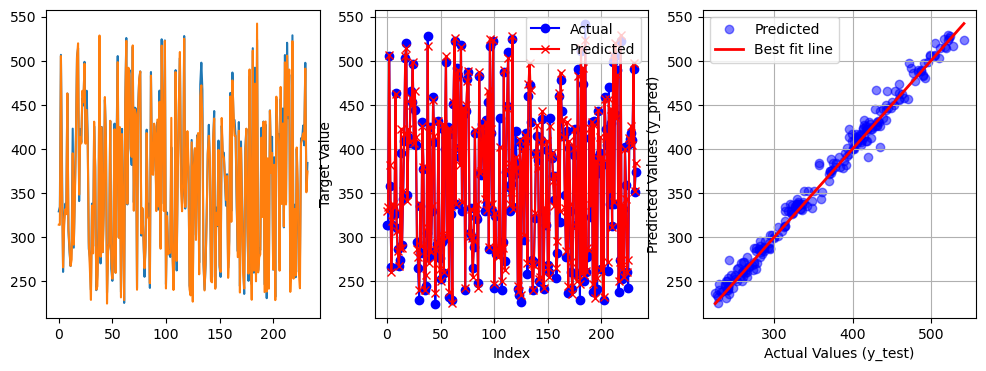

feature : high


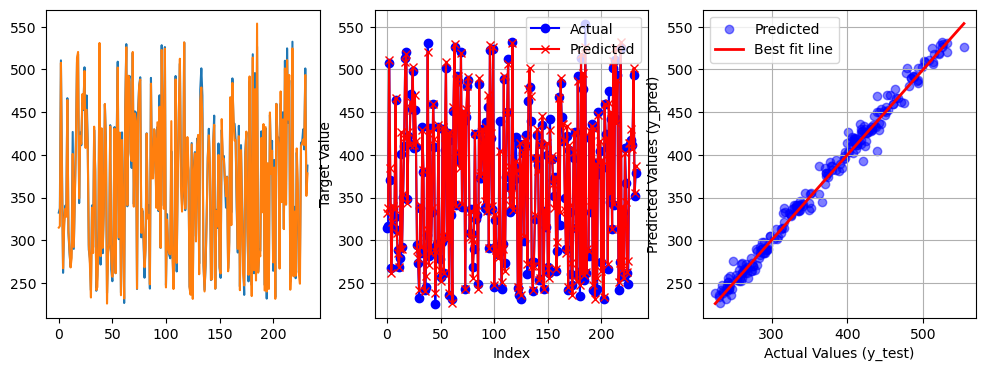

feature : low


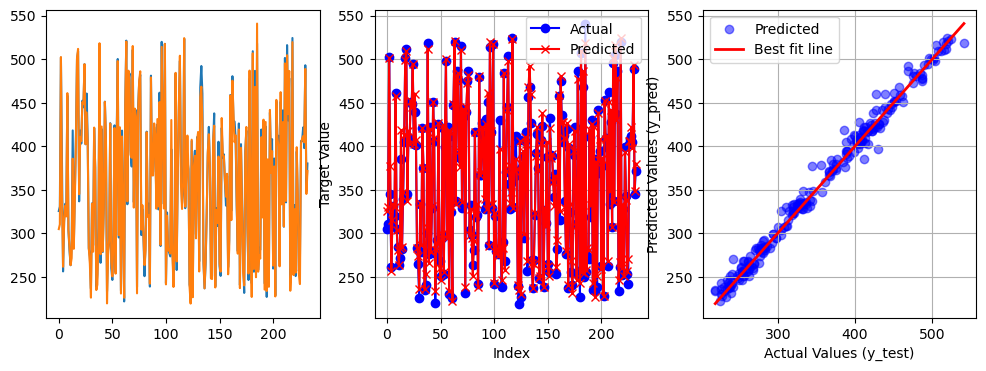

feature : open


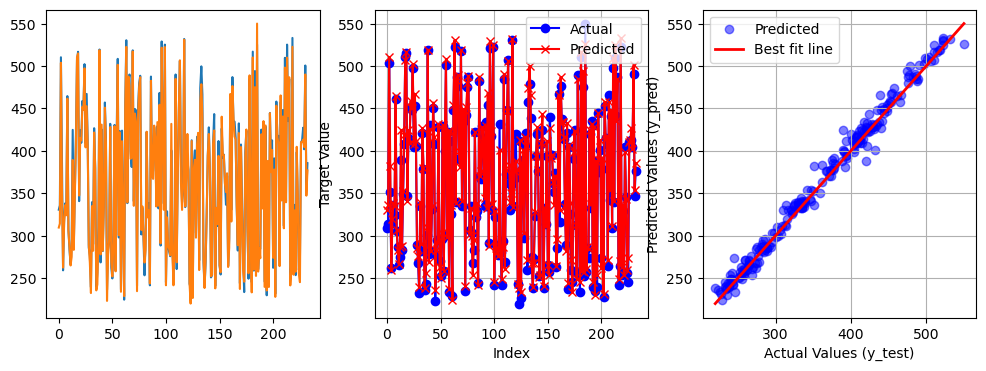

In [61]:
### plotting the comparison graphs now
for i in range(0, 4) : 
    print(f"feature : {features_to_target[i]}")
    plot_predictions(y_test[:, i], y_pred[:, i])

### Predicting the next 60 days of prices

In [62]:
future_days = 60
last_window = df_stock_MSFT[-future_days : ]
last_window

array([[0.60081752, 0.60183859, 0.59610679, 0.60549345],
       [0.60990788, 0.59512297, 0.59818415, 0.57288813],
       [0.54731255, 0.56079871, 0.54649461, 0.56234545],
       [0.57009944, 0.54136819, 0.54832757, 0.53783964],
       [0.60810811, 0.580468  , 0.57261432, 0.55467535],
       [0.60710146, 0.60670368, 0.60875423, 0.59841564],
       [0.57995241, 0.58515401, 0.57304201, 0.58821352],
       [0.57223476, 0.5545308 , 0.5638772 , 0.55511957],
       [0.57064853, 0.55256089, 0.5639994 , 0.55349078],
       [0.5570435 , 0.5375776 , 0.55323075, 0.53800252],
       [0.56540174, 0.54366643, 0.55871436, 0.53477456],
       [0.56192423, 0.54924785, 0.55978359, 0.54235582],
       [0.55817217, 0.53637148, 0.55517063, 0.52879248],
       [0.51924837, 0.52217646, 0.51832809, 0.52550529],
       [0.53306693, 0.50426815, 0.51408173, 0.49334419],
       [0.5684522 , 0.54041309, 0.53989595, 0.51225291],
       [0.57186871, 0.55838109, 0.56610731, 0.55426075],
       [0.54447563, 0.52653415,

In [63]:
### veryfying the shape
last_window.shape

(60, 4)

In [64]:
### reshaping it
last_window = np.expand_dims(last_window, axis = 0)
last_window.shape

(1, 60, 4)

In [65]:
### predicting the next 60 days price
future_preds = []
current_window = last_window.copy()

for _ in range(future_days) : 

    next_pred = model.predict(current_window, verbose = 0)
    future_preds.append(next_pred[0, : ])

    next_pred_reshaped = np.expand_dims(next_pred, axis = 0)
    current_window = np.concatenate(
        (last_window[:, 1 : , :], next_pred_reshaped), axis = 1
    )

In [66]:
future_preds

[array([0.66104496, 0.638698  , 0.65061617, 0.6357245 ], dtype=float32),
 array([0.66276425, 0.6404089 , 0.6523012 , 0.63747156], dtype=float32),
 array([0.6630271, 0.6406548, 0.6525568, 0.6377078], dtype=float32),
 array([0.66306657, 0.64069164, 0.65259486, 0.63774306], dtype=float32),
 array([0.66307235, 0.64069724, 0.6526006 , 0.63774836], dtype=float32),
 array([0.6630731 , 0.64069796, 0.6526015 , 0.63774925], dtype=float32),
 array([0.6630733 , 0.6406981 , 0.65260154, 0.6377493 ], dtype=float32),
 array([0.6630733, 0.6406981, 0.6526015, 0.6377494], dtype=float32),
 array([0.66307324, 0.6406981 , 0.65260154, 0.6377494 ], dtype=float32),
 array([0.6630733, 0.6406982, 0.6526015, 0.6377494], dtype=float32),
 array([0.6630733 , 0.6406981 , 0.65260154, 0.6377494 ], dtype=float32),
 array([0.6630733, 0.6406981, 0.6526015, 0.6377494], dtype=float32),
 array([0.66307324, 0.6406981 , 0.65260154, 0.6377494 ], dtype=float32),
 array([0.6630733, 0.6406982, 0.6526015, 0.6377494], dtype=float32)

In [67]:
future_preds = scaler.inverse_transform(future_preds)
future_preds

array([[430.95375723, 434.39937183, 426.40304614, 432.21826545],
       [431.51737684, 434.972589  , 426.95461998, 432.8082079 ],
       [431.60354645, 435.05498497, 427.03828283, 432.88799132],
       [431.61648166, 435.06732639, 427.05075031, 432.89988637],
       [431.618377  , 435.06920357, 427.05262336, 432.90167768],
       [431.61863102, 435.06944321, 427.05291602, 432.90197958],
       [431.61868964, 435.06948315, 427.05293553, 432.90199971],
       [431.61868964, 435.06948315, 427.05291602, 432.90201984],
       [431.6186701 , 435.06948315, 427.05293553, 432.90201984],
       [431.61868964, 435.06952309, 427.05291602, 432.90201984],
       [431.61868964, 435.06948315, 427.05293553, 432.90201984],
       [431.61868964, 435.06948315, 427.05291602, 432.90201984],
       [431.6186701 , 435.06948315, 427.05293553, 432.90201984],
       [431.61868964, 435.06952309, 427.05291602, 432.90201984],
       [431.61868964, 435.06948315, 427.05293553, 432.90201984],
       [431.61868964, 435

In [33]:
future_preds.shape

(60, 4)